- Cloth**Dataset** guarda la info d vertices x caracteristicas () al acceder a estos items con el **DataLoader** le añade la otra dimension d frames(batchsize) para crear el tensor3D
- Redondear valores para optimizar (ahorra memoria)

Otra idea sería:
> When to add a frame dimension (Sequence modeling): If your model needs temporal history—meaning it needs to look at, say, the last 5 frames to figure out what happens in the 6th frame. If you were using an LSTM, RNN, or a Spatiotemporal Transformer, your tensor would need to look like [Batch, Sequence_Length, Vertices, Features].
Por ahora no.

**Links Utilizados:**
- https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
- https://lixiaoguang.medium.com/build-cnn-from-scratch-5-convolutional-neural-network-86b4d0323fb0

In [1]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import io
import torch
import os, os.path

# WORKING WITH 
datasetPath = 'data/'

def loadAndMergeCSV(csvRoute):
    """
    Carga de los CSV y mergeo en un único CSV. Todos los CSV estarán en la ruta 'data/', y se excluirá el CSV
    'mergedCSV.csv', producto de los mergeos si se ejecutase antes
    """
    csvRoute= 'data/'
    finalData = pd.DataFrame()
    for csvfile in [f for f in os.listdir(csvRoute) if os.path.isfile(csvRoute + f)]:
        if (csvfile != 'mergedCSV.csv' and os.path.splitext(csvfile)[1] == '.csv'):
            data = pd.read_csv(csvRoute + csvfile)
            finalData = pd.concat([data, finalData], ignore_index=True)

    return finalData

cloth_info = loadAndMergeCSV(datasetPath)

print('cloth_info shape: {}'.format(cloth_info.shape))
print('cloth_info: \n{}'.format(cloth_info))

cloth_info shape: (1875, 79)
cloth_info: 
      frame        x0        y0        z0       vx0       vy0       vz0  \
0         0 -0.062031  1.586937 -0.300069  3.101573 -79.35066  0.344098   
1         1 -0.128177  1.588891 -0.296630  3.329991 -79.32870  0.354238   
2         2 -0.275654  1.613965 -0.300025  4.895734 -79.48515  0.322889   
3         3 -0.445346  1.678142 -0.298708  7.311562 -80.29195  0.346620   
4         4 -0.398109  1.656320 -0.298632  7.330228 -80.29503  0.325704   
...     ...       ...       ...       ...       ...       ...       ...   
1870   1870 -0.272841  1.613566 -0.299717  7.092755 -80.08585  0.333418   
1871   1871 -0.015944  1.588197 -0.300091  2.715977 -79.35562  0.344505   
1872   1872  0.242196  1.643511 -0.299520  0.788119 -79.56251  0.346778   
1873   1873  0.397415  1.722569 -0.300028 -2.586834 -81.16924  0.348875   
1874   1874 -0.041937  1.586794 -0.299935  1.060359 -79.44014  0.342573   

          sdf0       nx0       ny0  ...       vx5       v

C:\Users\Eva\AppData\Local\Temp\ipykernel_18008\4098661940.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')


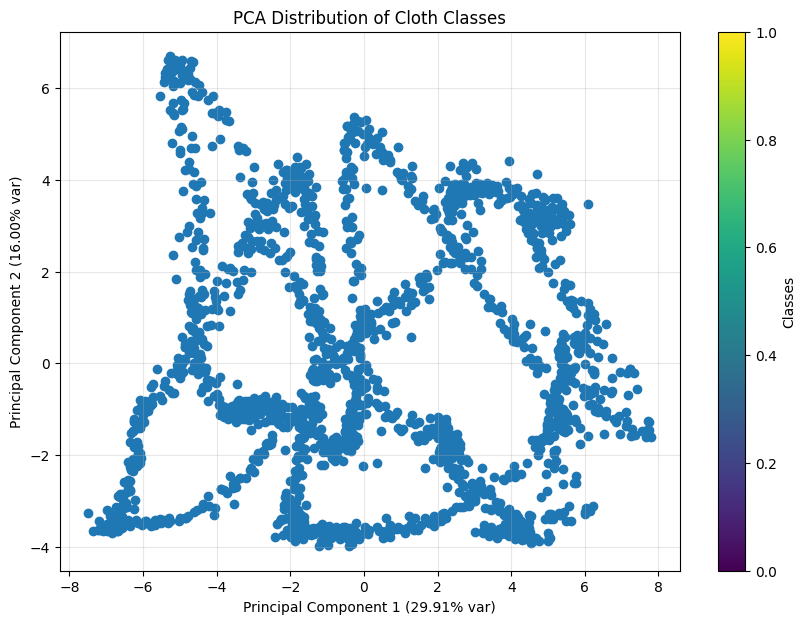

In [2]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import matplotlib.pyplot as plt

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_29_.csv') 

# EJ2 - representar distribucion de clases con PCA

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Visualizationplt.figure(figsize=(10, 7))
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')
plt.title('PCA Distribution of Cloth Classes')
plt.title('PCA Distribution of Cloth Classes')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.colorbar(scatter, label='Classes')
plt.grid(True, alpha=0.3)


plt.show()

In [3]:
class ClothDataset(Dataset):
    def __init__(self, csv_data, num_vertices=6):
        """
        Args:
            csv_data (str or filepath): Path to the CSV file or raw CSV string.
            num_vertices (int): Number of vertices per frame.
        """
        # Load the CSV data into a pandas DataFrame
        #if isinstance(csv_data, str) and "frame,x0" in csv_data:
            #self.data = pd.read_csv(io.StringIO(csv_data.strip()))
        #else:
            #self.data = pd.read_csv(csv_data)
        self.data = csv_data
            
        #quick fix para espacios en primera fila
        self.data.columns = self.data.columns.str.strip()
        
        self.num_vertices = num_vertices
        
        # Define the base feature names to extract per vertex
        self.feature_prefixes = ['x', 'y', 'z', 'sdf'] # 'vx', 'vy', 'vz',, 'nx', 'ny', 'nz', 'md', 'u', 'v'

        self.position_prefixes = ['x', 'y', 'z']
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')

        # Quitamos primera fila de outputs (no es el output de nada) y ultima fila de input (no tiene output)
        self.output_positions = self.output_positions.iloc[1:]
        self.data = self.data.iloc[:-1]
        

    def __len__(self):
        # The number of items is the number of frames (rows) in the dataset
        return len(self.data)
    
    def num_features(self):
        # Number of columns in a row (pos, vel, sdf, uv per vertex)
        return len(self.feature_prefixes)
    
    def num_vertex(self):
        return self.num_vertices
    
    def _get_frame_output_tensor(self, idx):
         row = self.output_positions.iloc[idx]
         frame_data = []
         for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.position_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

         tensor_data = torch.tensor(np.array(frame_data))

         return tensor_data
    
    def _get_frame_tensor(self, idx):
        row = self.data.iloc[idx]
        frame_data = []

        for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.feature_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

        tensor_data = torch.tensor(np.array(frame_data))

        return tensor_data
        
    def __getitem__(self, idx):
        frame_t = self._get_frame_tensor(idx)
        frame_t1 = self._get_frame_output_tensor(idx) # +1 ya no TODO: Pillar solo las columnas de pos

        return frame_t, frame_t1

# --- Example Usage ---

# (Assuming 'csv_string' is a variable holding your provided data block)
dataset = ClothDataset(cloth_info)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_data, batch_frames in dataloader:
    print(f"Batch Shape: {batch_data.shape}")
    print(batch_data)
    print(batch_frames)
    break



Batch Shape: torch.Size([4, 6, 4])
tensor([[[ 0.4410,  1.7525, -0.2999,  1.5715],
         [ 0.7152,  0.9633,  0.4712,  1.8136],
         [ 0.6251,  0.9279, -0.2849,  1.6271],
         [ 0.4634,  1.7698,  0.4619,  1.6982],
         [-0.0620,  2.4320, -0.3001,  1.5093],
         [-0.0620,  2.4320,  0.4621,  1.6132]],

        [[-0.0233,  1.5872, -0.2994,  0.0687],
         [-0.5482,  0.8925,  0.4295,  0.2973],
         [-0.4129,  0.8375, -0.3187, -0.0964],
         [-0.0670,  1.5864,  0.4616,  0.3645],
         [-0.0620,  2.4320, -0.3001,  0.9057],
         [-0.0620,  2.4320,  0.4621,  1.0506]],

        [[-0.3423,  1.6347, -0.2998,  0.8339],
         [-0.9369,  1.0182,  0.4492,  0.3775],
         [-0.9302,  1.0277, -0.3130,  0.1074],
         [-0.3703,  1.6450,  0.4619,  0.9678],
         [-0.0620,  2.4320, -0.3001,  1.5302],
         [-0.0620,  2.4320,  0.4621,  1.6331]],

        [[ 0.2377,  1.6419, -0.2999,  0.1232],
         [ 0.7322,  0.9649,  0.4692,  0.3737],
         [ 0.7831, 

In [4]:
# TODO
# una recurrente sencilla (la salida se vuelve entrada en el siguiente ejemplo)
# Antes de meternos en CNN y LSTM
# AÑADIMOS VALORES U V PARA CADA VERTICE ( no queremos perder la noción espacial )

import torch.nn as nn
import torch.nn.functional as F #acceso rapido a funciones
import torch.utils.data as data #cargar y manejar el training data

class MyModule(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Some init for my module
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Function for performing the calculation of the module.
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        #print(x)
        return x

    #backward se hace automaticamente, podriamos definirla tmbn 

#tmbn clases DataSet y DataLoader

# definir modelo, loss function y optimizer
#TODO: buscar dimensiones reales de las neuronas

# nn.Linear in PyTorch is designed to handle 3D tensors seamlessly.  
# When a 3D input tensor (e.g., batch_size, sequence_length, features) is provided,
#  the layer applies the linear transformation only to the last dimension (the features dimension),
#  preserving all other dimensions.


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np

# ... [Keep your ClothDataset and MyModule classes exactly as they are] ...

dataset = ClothDataset(cloth_info)

# 1. SPLIT THE DATA (80% Training, 20% Testing)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False) # No need to shuffle test data

# 2. COMPUTE GLOBAL STATS (Only on training data to prevent data leakage)
# Correct Python logic for mean/std
all_inputs = []
all_targets = []

for batch_t, batch_t1 in dataloader:
    # Flatten batch and vertices: (Batch * Vertices, Features)
    all_inputs.append(batch_t.view(-1, 4))
    
    # Do the same for targets (displacements)
    pos_t = batch_t[..., 0:3]
    delta = batch_t1 - pos_t
    all_targets.append(delta.view(-1, 3))

# Combine everything
full_input_tensor = torch.cat(all_inputs, dim=0)
full_target_tensor = torch.cat(all_targets, dim=0)

# Calculate Global Stats
input_mean = full_input_tensor.mean(dim=0)
input_std = full_input_tensor.std(dim=0)
target_mean = full_target_tensor.mean(dim=0)
target_std = full_target_tensor.std(dim=0)

# Save to JSON
norm_data = {
    "mean": input_mean.tolist(),
    "std": input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std": target_std.tolist()
}
# ... save as json ...
import json

with open("cloth_norm_params.json", "w") as f:
    json.dump(norm_data, f)

# 3. SETUP MODEL
model = MyModule(num_inputs=4, num_hidden=64, num_outputs=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
print("start training")

# 4. TRAINING & TESTING LOOP
epochs = 50
for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    train_loss = 0.0
    
    for batch_t, batch_t1 in train_loader:
        batch_t = batch_t.float()
        batch_t1 = batch_t1.float()

        # Normalize Input globally
        batch_t_norm = (batch_t - input_mean) / input_std

        # Target is the DISPLACEMENT (Delta), not the absolute position
        positions_t = batch_t[..., 0:3] 
        target_delta = batch_t1 - positions_t
        
        # Note: For best results, target_delta should also be globally normalized, 
        # but we will keep it raw here for easier "Distance Error" calculation later.

        pred_delta = model(batch_t_norm)
        loss = criterion(pred_delta, target_delta)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f'Train Epoch {epoch+1:03d}')
        
    avg_train_loss = train_loss / len(train_loader)

    # --- TESTING/VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    total_distance_error = 0.0
    total_vertices = 0

    all_pred_deltas = []
    all_target_deltas = []

    all_pred_pos = []
    all_target_pos = []
    
    with torch.no_grad(): # Disable gradient calculation for testing (saves memory & speeds up)
        for batch_t, batch_t1 in test_loader:
            batch_t = batch_t.float()
            batch_t1 = batch_t1.float()

            batch_t_norm = (batch_t - input_mean) / input_std
            
            positions_t = batch_t[..., 0:3] 
            target_delta = batch_t1 - positions_t

            pred_delta = model(batch_t_norm)
            loss = criterion(pred_delta, target_delta)
            test_loss += loss.item()

            # --- NEW: Reconstruct the absolute positions ---
            pred_pos = positions_t + pred_delta
            target_pos = batch_t1[..., 0:3] # The true final position

            # Store them
            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())
            
            # Calculate our "Accuracy" (Mean Distance Error per vertex)
            # Distance = sqrt((dx_pred - dx_true)^2 + (dy_pred - dy_true)^2 + (dz_pred - dz_true)^2)
            distances = torch.norm(pred_delta - target_delta, dim=-1) # Calculates Euclidean distance
            total_distance_error += distances.sum().item()
            total_vertices += distances.numel()

            # --- NEW: Store the data for PCA ---
            # Move tensors to the CPU and convert to NumPy arrays immediately
            all_pred_deltas.append(pred_delta.cpu().numpy())
            all_target_deltas.append(target_delta.cpu().numpy())

            print(f'Epoch {epoch+1:03d} | Test Loss: {test_loss:.6f} | Vertex Error: {total_distance_error:.6f} units')

    avg_test_loss = test_loss / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    # Combine into large arrays
    # Shapes will be: (Total_Frames, Vertices, 3)
    preds_pos_np = np.concatenate(all_pred_pos, axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    print(f'Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f} | Avg Vertex Error: {avg_distance_error:.6f} units')


start training
Train Epoch 001
Epoch 001 | Test Loss: 0.047336 | Vertex Error: 6.852593 units
Epoch 001 | Test Loss: 0.081838 | Vertex Error: 12.626104 units
Epoch 001 | Test Loss: 0.120895 | Vertex Error: 18.867254 units
Epoch 001 | Test Loss: 0.168429 | Vertex Error: 25.483836 units
Epoch 001 | Test Loss: 0.214352 | Vertex Error: 32.472685 units
Epoch 001 | Test Loss: 0.248311 | Vertex Error: 38.486329 units
Epoch 001 | Test Loss: 0.274131 | Vertex Error: 42.878948 units
Epoch 001 | Test Loss: 0.329812 | Vertex Error: 50.616240 units
Epoch 001 | Test Loss: 0.376551 | Vertex Error: 57.350336 units
Epoch 001 | Test Loss: 0.397417 | Vertex Error: 62.053451 units
Epoch 001 | Test Loss: 0.415330 | Vertex Error: 66.247933 units
Epoch 001 | Test Loss: 0.450099 | Vertex Error: 72.008307 units
Epoch 001 | Test Loss: 0.494206 | Vertex Error: 78.170849 units
Epoch 001 | Test Loss: 0.535047 | Vertex Error: 84.404276 units
Epoch 001 | Test Loss: 0.564780 | Vertex Error: 89.717800 units
Epoch 001 

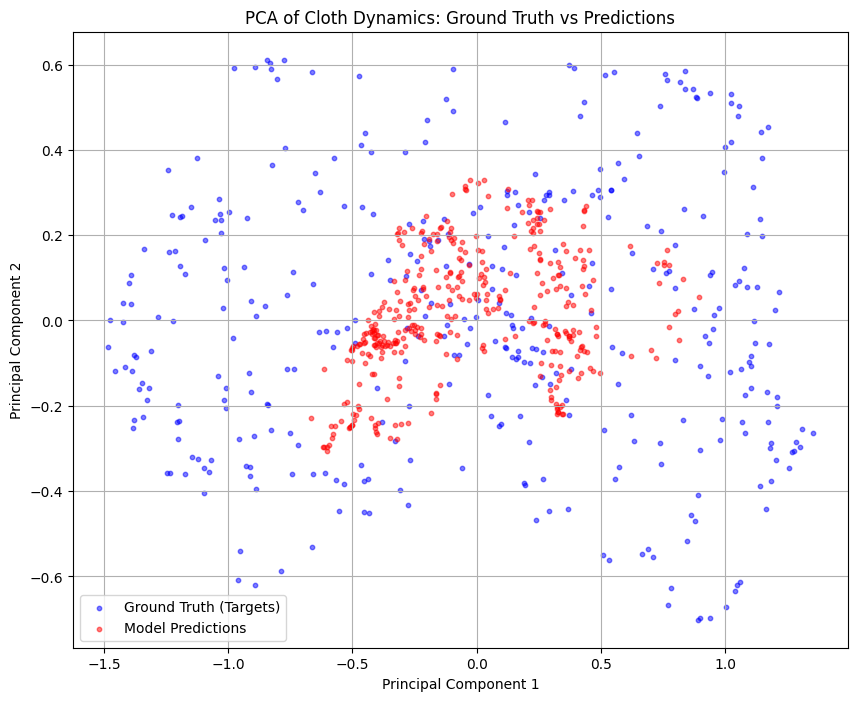

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

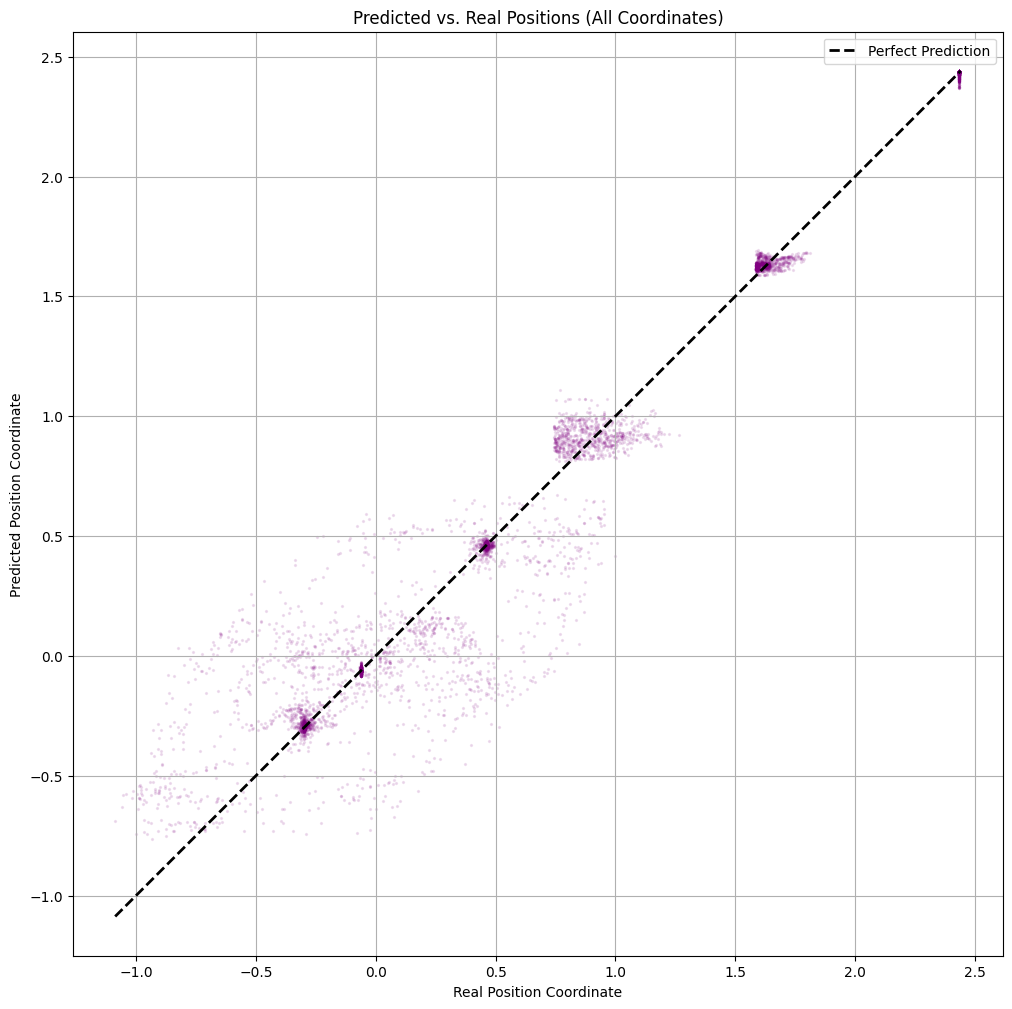

In [7]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

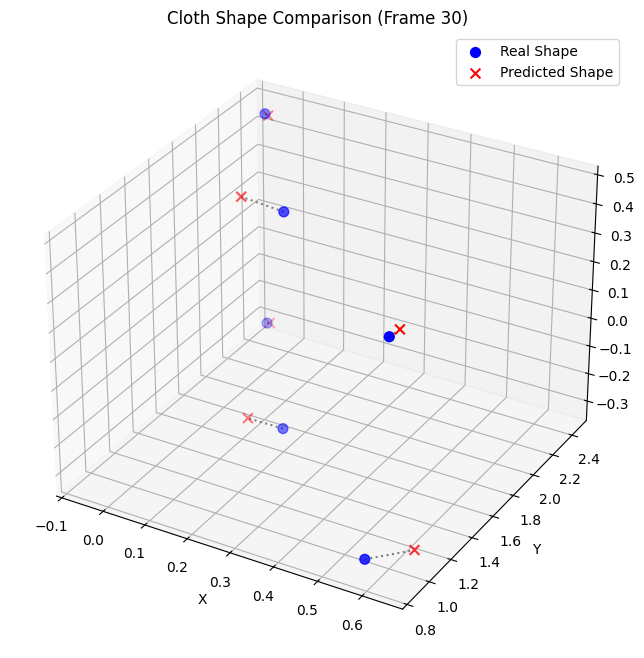

In [8]:
# Choose a random frame from your test set to visualize
frame_idx = 30 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [9]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. Create a dummy input strictly enforcing the 3D shape: (Batch=3, Vertices=6, Features=13)
# It doesn't matter what the numbers are, ONNX just needs the shape.
dummy_input = torch.randn(1, 6, 4)

# 3. Export to ONNX
onnx_program = torch.onnx.export(
    model,                      # Your trained PyTorch model
    dummy_input,                # The strictly 3D input tensor
    "cloth_pos_local.onnx",         # Output file name
    export_params=True,         # Store the trained weights
    opset_version=9,            # Sentis handles opset 9-15 well
    input_names=['input'],      # Name the input for Unity
    output_names=['output'],    # Name the output for Unity
)

print("Exported to ONNX with strict 3D shapes!")

Exported to ONNX with strict 3D shapes!
